In [137]:
import astropy.io.fits as fits
import astropy.units as u
from astropy.nddata import Cutout2D
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np
import aplpy
import pandas as pd
from scipy.ndimage import rotate
from astropy.wcs import WCS
from astropy.constants import c

import warnings
warnings.filterwarnings("ignore")

In [138]:
def create_fig_legacy(img, distance=0):
    # Create FITSFigure
    fig = aplpy.FITSFigure(img, figure=plt.figure(figsize=(6,6)))

    # Display image
    fig.show_colorscale(cmap='viridis', stretch='sqrt')

    # Title
    fig.set_title(img.header['OBJECT'])

    # Colorbar
    fig.add_colorbar()
    fig.colorbar.set_axis_label_text("Intensity (Jy/Beam)")
    fig.colorbar.set_location('right')
    fig.colorbar.set_pad(0.0)

    # Scalebar
    if distance == 0:
        fig.add_scalebar(1 * u.arcsecond)
        fig.scalebar.set_label('1"')
    else:
        fig.add_scalebar((500 / (distance)) * u.arcsecond)
        fig.scalebar.set_label('500 AU')
        fig.scalebar.set_font_size(8)

    fig.scalebar.set_linewidth(3)

    # Beam
    fig.add_beam()
    fig.beam.show()
    fig.beam.set_corner("bottom left")
    fig.beam.set_color("black")
    fig.beam.set_edgecolor("black")
    fig.beam.set_facecolor("white")

    return fig

In [139]:
# open image
# image_filename = "/Volumes/Alpha/Research/data/hops-168/hops-168__s15__12co.fits"
# rotation_angle = 159.35
# image_filename = "/Volumes/Alpha/Research/data/hops-312/hops-312__s15__12co.fits"
# rotation_angle = 216.3725
image_filename = "/Volumes/Alpha/Research/data/hops-364/hops-364__s15__12co.fits"
rotation_angle = 276.3025
hdulist = fits.open(image_filename)    
hdu = hdulist[0]

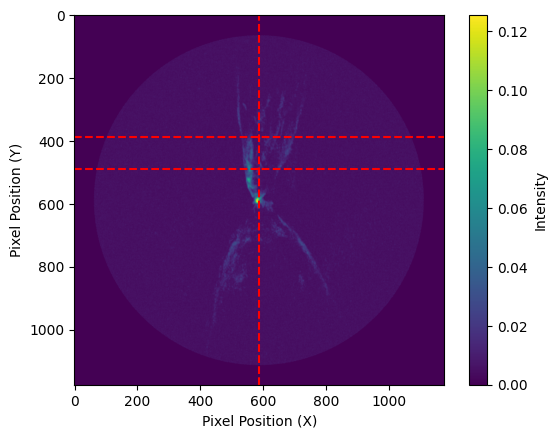

In [140]:
# create map
cube = hdu.data[0,:,:,:]
rotated_cube = np.array([rotate(cube[v], rotation_angle, reshape=False, order=1) for v in range(cube.shape[0])])
center_col = rotated_cube.shape[2] // 2
perp_line_1 = rotated_cube.shape[1] // 2 - 100
perp_line_2 = rotated_cube.shape[1] // 2 - 200

m8_map = np.max(rotated_cube, axis=0)

plt.imshow(np.nan_to_num(m8_map, nan=0.0))
plt.axvline(center_col, color='red', linestyle='--')
plt.axhline(perp_line_1, color='red', linestyle='--')
plt.axhline(perp_line_2, color='red', linestyle='--')
plt.xlabel("Pixel Position (X)")
plt.ylabel("Pixel Position (Y)")
plt.colorbar(label="Intensity")
plt.show()

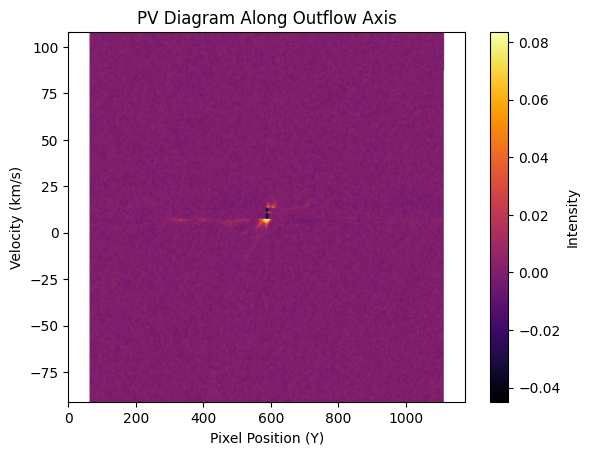

In [141]:
wcs = WCS(hdu.header)

# Velocity axis conversion
nu_rest = 230.538e9  # 12CO J=2-1 rest freq
vel_pix = np.arange(cube.shape[0])
freq_axis = wcs.all_pix2world(0, 0, vel_pix, 0, 0)[2]
vel_axis = ((nu_rest - freq_axis) / nu_rest) * c.to('km/s').value

plt.imshow(rotated_cube[:, :, center_col], origin='lower', aspect='auto',
           extent=[0, rotated_cube.shape[1], vel_axis[0], vel_axis[-1]],
           cmap='inferno')
plt.xlabel('Pixel Position (Y)')
plt.ylabel('Velocity (km/s)')
plt.title('PV Diagram Along Outflow Axis')
plt.colorbar(label='Intensity')
plt.show()

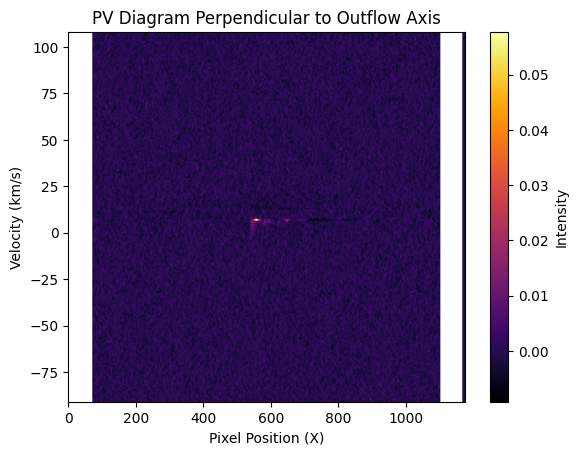

In [142]:
wcs = WCS(hdu.header)

# Velocity axis conversion
nu_rest = 230.538e9  # 12CO J=2-1 rest freq
vel_pix = np.arange(cube.shape[0])
freq_axis = wcs.all_pix2world(0, 0, vel_pix, 0, 0)[2]
vel_axis = ((nu_rest - freq_axis) / nu_rest) * c.to('km/s').value

plt.imshow(rotated_cube[:, perp_line_1, :], origin='lower', aspect='auto',
           extent=[0, rotated_cube.shape[1], vel_axis[0], vel_axis[-1]],
           cmap='inferno')
plt.xlabel('Pixel Position (X)')
plt.ylabel('Velocity (km/s)')
plt.title('PV Diagram Perpendicular to Outflow Axis')
plt.colorbar(label='Intensity')
plt.show()

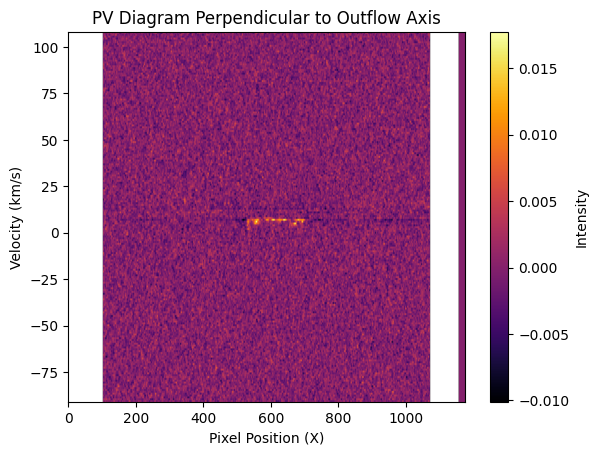

In [143]:
wcs = WCS(hdu.header)

# Velocity axis conversion
nu_rest = 230.538e9  # 12CO J=2-1 rest freq
vel_pix = np.arange(cube.shape[0])
freq_axis = wcs.all_pix2world(0, 0, vel_pix, 0, 0)[2]
vel_axis = ((nu_rest - freq_axis) / nu_rest) * c.to('km/s').value

plt.imshow(rotated_cube[:, perp_line_2, :], origin='lower', aspect='auto',
           extent=[0, rotated_cube.shape[1], vel_axis[0], vel_axis[-1]],
           cmap='inferno')
plt.xlabel('Pixel Position (X)')
plt.ylabel('Velocity (km/s)')
plt.title('PV Diagram Perpendicular to Outflow Axis')
plt.colorbar(label='Intensity')
plt.show()